Path (4 steps):  R1  →  R22  →  R18  →  R10


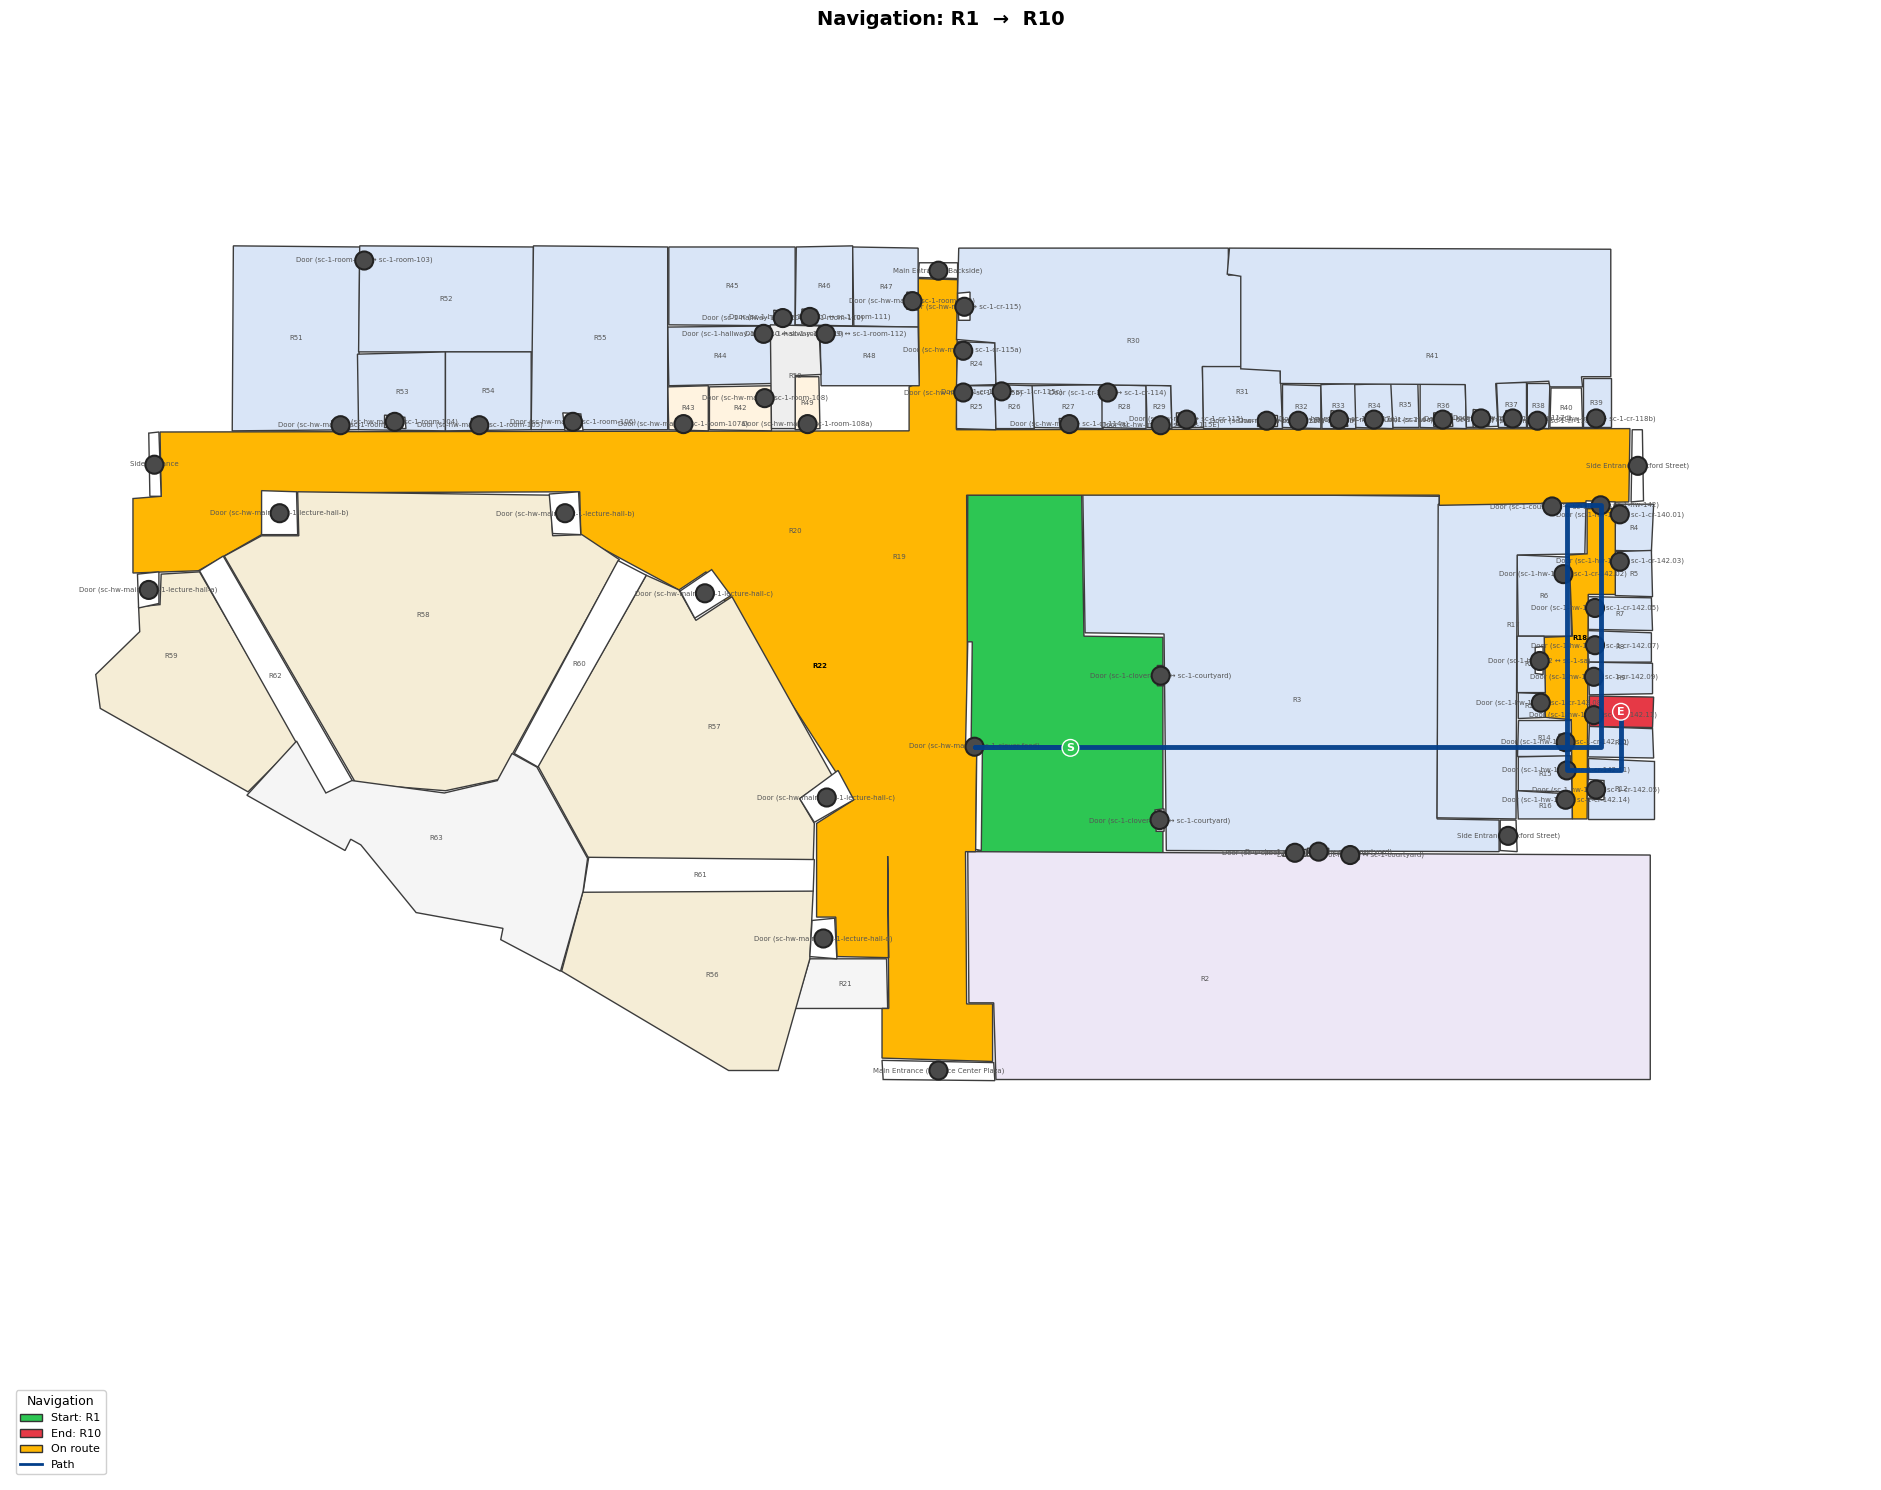


Available rooms (for navigation):
  R1         R10        R11        R12        R13     
  R14        R15        R16        R17        R18     
  R19        R2         R20        R21        R22     
  R23        R24        R25        R26        R27     
  R28        R29        R3         R30        R31     
  R32        R33        R34        R35        R36     
  R37        R38        R39        R4         R40     
  R41        R42        R43        R44        R45     
  R46        R47        R48        R49        R5      
  R50        R51        R52        R53        R54     
  R55        R56        R57        R58        R59     
  R6         R60        R61        R62        R63     
  R7         R8         R9      


In [1]:
# ── Interactive Navigation with BFS Pathfinding ──
# Set START and END to any room name (e.g., "R1", "R5", etc.)

START = "R1"
END   = "R10"

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from collections import deque

with open('Floor Plans/floor1_round_doors.json') as f:
    floor1s = json.load(f)

# Renumber non-door rooms to R[Number]
room_counter = 1
for room in floor1s['rooms']:
    if room.get('symbol', ''):
        continue
    is_door = room['type'] in ('door', 'entrance', 'connection')
    if not is_door:
        room['name'] = f'R{room_counter}'
        room_counter += 1

rooms_by_id   = {r['id']: r for r in floor1s['rooms']}
rooms_by_name = {r['name'].lower(): r['id']
                 for r in floor1s['rooms'] if r.get('name')}

TRAVERSABLE = {'corridor', 'connection', 'door', 'entrance', 'stairwell', 'elevator'}

W = floor1s['viewBox']['width']
H = floor1s['viewBox']['height']

door_entities = [r for r in floor1s['rooms'] if r['type'] in ('door', 'entrance', 'connection')]

def resolve(query):
    q = query.lower()
    if q in rooms_by_id:   return q
    if q in rooms_by_name: return rooms_by_name[q]
    matches = [rid for name, rid in rooms_by_name.items() if q in name]
    if len(matches) == 1:  return matches[0]
    if len(matches) > 1:
        raise ValueError(f"Ambiguous — did you mean: {[rooms_by_id[m]['name'] for m in matches]}")
    raise ValueError(f"Room not found: '{query}'")

def bfs(start_id, end_id):
    """Shortest path through hallways/doors only; rooms are only start/end."""
    visited = {start_id}
    queue   = deque([[start_id]])
    while queue:
        path = queue.popleft()
        if path[-1] == end_id:
            return path
        for nb in rooms_by_id.get(path[-1], {}).get('neighbors', []):
            if nb not in visited and nb in rooms_by_id:
                if nb == end_id or rooms_by_id[nb]['type'] in TRAVERSABLE:
                    visited.add(nb)
                    queue.append(path + [nb])
    return None

def find_door_pos(a_id, b_id):
    """Return (x, y) of the door entity connecting room a and room b."""
    for d in door_entities:
        connects = d.get('connects', [])
        if (a_id in connects and b_id in connects):
            la = d.get('labelAnchor', {})
            if la:
                return (la['x'], H - la['y'])
    return None

def build_path_vertices(route_xy):
    """Build path with mixed routing strategy."""
    if len(route_xy) < 2:
        return list(route_xy)
    start = route_xy[0]
    end   = route_xy[-1]
    doors = route_xy[1:-1]
    verts = [start]
    if doors:
        verts.append((start[0], doors[0][1]))
        verts.append(doors[0])
        for i in range(len(doors) - 1):
            x0, y0 = doors[i]
            x1, y1 = doors[i + 1]
            verts.append((x1, y0))
            verts.append((x1, y1))
        verts.append((end[0], doors[-1][1]))
        verts.append(end)
    else:
        verts.append((start[0], end[1]))
        verts.append(end)
    return verts

# Find path
start_id = resolve(START)
end_id   = resolve(END)
path_ids = bfs(start_id, end_id)

if path_ids is None:
    print(f"No path found from '{START}' to '{END}'.")
    print("Check that both rooms connect via indoor hallways/doors.")
else:
    path_names = [rooms_by_id[p]['name'] or p for p in path_ids]
    print(f"Path ({len(path_ids)} steps):  " + "  →  ".join(path_names))

    route_xy = []
    la = rooms_by_id[start_id].get('labelAnchor', {})
    if la:
        route_xy.append((la['x'], H - la['y']))

    for i in range(len(path_ids) - 1):
        door_pos = find_door_pos(path_ids[i], path_ids[i + 1])
        if door_pos:
            route_xy.append(door_pos)

    la = rooms_by_id[end_id].get('labelAnchor', {})
    if la:
        route_xy.append((la['x'], H - la['y']))

    # Render navigation map
    TYPE_COLORS = {
        'classroom': '#D9E5F7', 'lecture':  '#F5EDD6', 'lobby':    '#FDF6E3',
        'corridor':  '#EEEEEE', 'connection':'#E0F7FA', 'door':     '#FFFFFF',
        'entrance':  '#FFFFFF', 'lab':      '#DAF0DE', 'library':  '#EDE7F6',
        'stairwell': '#FFFFFF', 'elevator': '#CFD8DC', 'office':   '#FFF3E0',
        'other':     '#F5F5F5',
    }
    PATH_COLOR  = '#FFB703'
    START_COLOR = '#2DC653'
    END_COLOR   = '#E63946'
    LINE_COLOR  = '#023E8A'
    path_set = set(path_ids)

    fig, ax = plt.subplots(figsize=(20, 15))
    ax.set_facecolor('#E8E0D0')
    fig.patch.set_facecolor('#FFFFFF')

    # Draw regular rooms
    for room in floor1s['rooms']:
        if room.get('symbol', ''):
            continue
        pts = np.array(room['polygon'], dtype=float)
        pts[:, 1] = H - pts[:, 1]
        rid = room['id']
        if rid == start_id:      fc = START_COLOR
        elif rid == end_id:      fc = END_COLOR
        elif rid in path_set:    fc = PATH_COLOR
        else:                    fc = TYPE_COLORS.get(room['type'], '#EEEEEE')
        ax.add_patch(Polygon(pts, closed=True, facecolor=fc,
                             edgecolor='#3C3C3C', linewidth=1.0, zorder=2))
        if room['name']:
            cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
            ax.text(cx, cy, room['name'], ha='center', va='center',
                    fontsize=5,
                    fontweight='bold' if rid in path_set else 'normal',
                    color='#000' if rid in path_set else '#555', zorder=3)

    # Draw stairwells
    for room in floor1s['rooms']:
        if room.get('symbol', '') != 'hatch_diagonal':
            continue
        pts = np.array(room['polygon'], dtype=float)
        pts[:, 1] = H - pts[:, 1]
        bw = pts[:, 0].max() - pts[:, 0].min()
        bh = pts[:, 1].max() - pts[:, 1].min()
        hatch = '--' if bh >= bw else '||'
        fc = PATH_COLOR if room['id'] in path_set else 'white'
        ax.add_patch(Polygon(pts, closed=True, facecolor=fc,
                             edgecolor='#3C3C3C', hatch=hatch,
                             linewidth=1.2, zorder=4))

    # Draw doors
    for room in floor1s['rooms']:
        if room['type'] not in ('door', 'entrance', 'connection'):
            continue
        la = room.get('labelAnchor', {})
        if la:
            circle = plt.Circle((la['x'], H - la['y']), 8,
                               facecolor='#4A4A4A', edgecolor='#222222',
                               linewidth=1.5, zorder=5)
            ax.add_patch(circle)

    # Draw path
    if len(route_xy) >= 2:
        verts = build_path_vertices(route_xy)
        xs = [p[0] for p in verts]
        ys = [p[1] for p in verts]
        ax.plot(xs, ys, color=LINE_COLOR, linewidth=3.5,
                linestyle='-', zorder=6, alpha=0.95,
                solid_capstyle='round', solid_joinstyle='round')

        for i, (x, y) in enumerate(route_xy):
            if i == 0:
                label, fc_ = 'S', START_COLOR
            elif i == len(route_xy) - 1:
                label, fc_ = 'E', END_COLOR
            else:
                continue
            ax.text(x, y, label, ha='center', va='center', fontsize=8,
                    fontweight='bold', color='white', zorder=9,
                    bbox=dict(boxstyle='circle,pad=0.3', facecolor=fc_,
                              edgecolor='white', linewidth=1))

    legend_entries = [
        mpatches.Patch(facecolor=START_COLOR, edgecolor='#333',
                       label=f'Start: {rooms_by_id[start_id]["name"]}'),
        mpatches.Patch(facecolor=END_COLOR,   edgecolor='#333',
                       label=f'End: {rooms_by_id[end_id]["name"]}'),
        mpatches.Patch(facecolor=PATH_COLOR,  edgecolor='#333', label='On route'),
        Line2D([0], [0], color=LINE_COLOR, linewidth=2, label='Path'),
    ]
    ax.legend(handles=legend_entries, loc='lower left',
              fontsize=8, framealpha=0.92, title='Navigation', title_fontsize=9)
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect('equal')
    ax.set_title(
        f'Navigation: {rooms_by_id[start_id]["name"]}  →  {rooms_by_id[end_id]["name"]}',
        fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\nAvailable rooms (for navigation):")
nav_rooms = sorted(
    {r['name'] for r in floor1s['rooms']
     if r.get('name') and r['type'] not in ('door', 'entrance', 'connection')},
    key=str.lower
)
for i in range(0, len(nav_rooms), 5):
    print("  " + "   ".join(f"{n:<8}" for n in nav_rooms[i:i+5]))